In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import RMSprop


# **Environment Setup**

In [2]:
#loaded the data both are the different files here train and test so thats why two different variables 
#because of two different files
train = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')

In [3]:
#now its time to get the train and test data ready label column is target coulmn has values 0-9
#i will drop the label for train and test for X
X = train.drop('label', axis=1).values
y = train['label'].values

In [4]:
X_test = test.drop('label', axis=1).values
y_test = test['label'].values

In [5]:
#now i will normalize the values for this i recalled my ds concept to use minmax scalar
# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

#here i tried to use minmax scalar but by which i was getting a value of 1.3 in test.max() 
#but the assignment requirement was 0-1 so i divided it with max number 255

X = X / 255.0
X_test = X_test / 255.0

print("Training shape:", X.shape)
print("Test shape:", X_test.shape)
print("Training min:", X.min())
print("Training max:", X.max())
print("Test min:", X_test.min())
print("Test max:", X_test.max())

Training shape: (60000, 784)
Test shape: (10000, 784)
Training min: 0.0
Training max: 1.0
Test min: 0.0
Test max: 1.0


In [6]:
#data has already 784 columns so it is falattend already
print("X shape:", X.shape)
print("Test shape:", X_test.shape)

X shape: (60000, 784)
Test shape: (10000, 784)


In [7]:
#train test validation splitting 
#number of sample in each split
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [8]:
#class distritbution 0-9
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())


Training class distribution:
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Validation class distribution:
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64

Test class distribution:
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


# PART 1

In [9]:
# ReLU function for hidden layers
def relu(x):
    return np.maximum(0, x)

# Derivative of ReLU
def relu_derivative(x):
    return (x > 0).astype(float)

# Softmax for activation
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# one-hot encoding
def one_hot(y, classes):
    result = np.zeros((y.size, classes))
    result[np.arange(y.size), y] = 1
    return result

# Categorial Cross Entropy Loss Fucntion
def calculate_loss(y, output):
    m = y.shape[0]
    return -np.sum(y * np.log(output + 1e-15)) / m

In [10]:
np.random.seed(42)

#weights and bias
W1 = np.random.randn(784,64) * 0.01
b1 = np.zeros((1, 64))
W2 = np.random.randn(64, 10) * 0.01
b2 = np.zeros((1,10))


#i have to copy for torch
W1_initial = W1.copy()
b1_initial = b1.copy()
W2_initial = W2.copy()
b2_initial = b2.copy()

In [11]:
#Taking only 5000 training samples
X = X_train[0:5000]
y = y_train[0:5000]

#for pytorch need a copy
X_batch = X
y_batch = y

#one-hot encoding for categoeries
y_one_hot = one_hot(y, 10)


#here we will see the results of epochs after 5 iterations
epochs = 20
learning_rate = 0.1
losses = []
for epoch in range(epochs):
    #forward
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    loss = calculate_loss(y_one_hot, A2)
    losses.append(loss)

    # Backpropagation
    m = X.shape[0]
    dZ2 = (A2 - y_one_hot) / m
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    #Update
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    if (epoch + 1) % 5 == 0:
        print("Epoch:", epoch + 1, "Loss:", loss)

Epoch: 5 Loss: 2.2980597178845135
Epoch: 10 Loss: 2.2863589031136797
Epoch: 15 Loss: 2.262202776536237
Epoch: 20 Loss: 2.2150265810148526


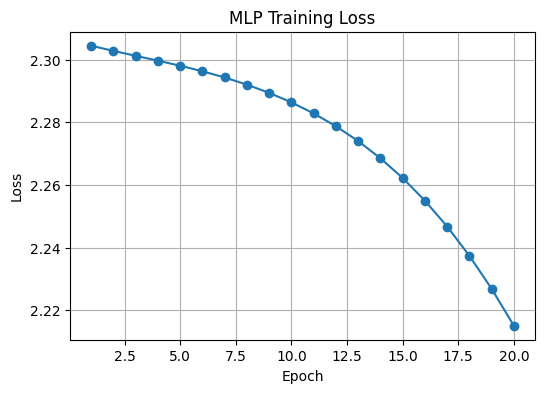

In [12]:
# Plot the loss
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), losses, marker='o')
plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [13]:
#pytorch
model = nn.Sequential(nn.Linear(784, 64),nn.ReLU(),
    nn.Linear(64, 10))

#the copies i created in upper cell will be used here 
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(W1_initial.T))
    model[0].bias.copy_(torch.tensor(b1_initial.flatten()))

    model[2].weight.copy_(torch.tensor(W2_initial.T))
    model[2].bias.copy_(torch.tensor(b2_initial.flatten()))

In [14]:
X_torch = torch.tensor(X_batch, dtype=torch.float32)
y_torch = torch.tensor(y_batch, dtype=torch.long)

#Forward
output = model(X_torch)

#loss
loss = nn.CrossEntropyLoss()(output, y_torch)

#Backward
loss.backward()

In [15]:
#pytorch gradiet
dW1_torch = model[0].weight.grad.numpy().T
dW2_torch = model[2].weight.grad.numpy().T

In [16]:
#absolute differ
difference_W1 = np.max(np.abs(dW1 - dW1_torch))
difference_W2 = np.max(np.abs(dW2 - dW2_torch))

print("Maximum difference for W1:", difference_W1)
print("Maximum difference for W2:", difference_W2)


Maximum difference for W1: 0.006655703253986288
Maximum difference for W2: 0.030647578993040124


# PART 2

In [17]:
np.random.seed(42)
tf.random.set_seed(42)

#encoding
y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)

In [18]:
X_grad_sample = X_val[0:128]
y_grad_sample = y_val_cat[0:128]

In [19]:
#this will get the gradient i get the issue and get to know
#fit() doesnt give me graident so this will get it
class GradientLogger(tf.keras.callbacks.Callback):
    def __init__(self, X_sample, y_sample):
        super().__init__()
        self.X_sample = X_sample
        self.y_sample = y_sample
        self.grad_history = []

    def on_epoch_end(self, epoch, logs=None):
        with tf.GradientTape() as tape:
            preds = self.model(self.X_sample, training=True)
            loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(self.y_sample, preds))

        first_layer_w = self.model.layers[0].trainable_weights[0]
        grad = tape.gradient(loss, [first_layer_w])[0]
        self.grad_history.append(tf.reduce_mean(tf.abs(grad)).numpy())

In [20]:
#Sigmoid
sigmoid_model = Sequential([
    Dense(128, input_dim=784, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(10, activation='softmax')
])

sigmoid_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

sigmoid_logger = GradientLogger(X_grad_sample, y_grad_sample)

sigmoid_history = sigmoid_model.fit(X_train, y_train_cat,
                                     validation_data=(X_val, y_val_cat),
                                     epochs=5, batch_size=128,
                                     callbacks=[sigmoid_logger],
                                     verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1789244239.748716      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789244239.751732      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/5
 68/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3517 - loss: 2.0682

I0000 00:00:1789244243.773116     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7184 - loss: 0.9442 - val_accuracy: 0.8122 - val_loss: 0.5567
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8319 - loss: 0.4836 - val_accuracy: 0.8331 - val_loss: 0.4534
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8519 - loss: 0.4155 - val_accuracy: 0.8457 - val_loss: 0.4166
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8638 - loss: 0.3827 - val_accuracy: 0.8551 - val_loss: 0.3958
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8715 - loss: 0.3607 - val_accuracy: 0.8624 - val_loss: 0.3817


In [21]:
#TANH
tanh_model = Sequential([
    Dense(128, input_dim=784, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(10, activation='softmax')
])

tanh_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

tanh_logger = GradientLogger(X_grad_sample, y_grad_sample)

tanh_history = tanh_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=5, batch_size=128,
                               callbacks=[tanh_logger],
                               verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8096 - loss: 0.5482 - val_accuracy: 0.8175 - val_loss: 0.4808
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8594 - loss: 0.3952 - val_accuracy: 0.8357 - val_loss: 0.4334
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8727 - loss: 0.3574 - val_accuracy: 0.8457 - val_loss: 0.4083
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8806 - loss: 0.3319 - val_accuracy: 0.8511 - val_loss: 0.3920
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8875 - loss: 0.3119 - val_accuracy: 0.8569 - val_loss: 0.3788


In [22]:
#RELU 
relu_model = Sequential([
    Dense(128, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

relu_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

relu_logger = GradientLogger(X_grad_sample, y_grad_sample)

relu_history = relu_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=5, batch_size=128,
                               callbacks=[relu_logger],
                               verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8020 - loss: 0.5817 - val_accuracy: 0.8430 - val_loss: 0.4396
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8566 - loss: 0.4057 - val_accuracy: 0.8477 - val_loss: 0.4105
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8697 - loss: 0.3646 - val_accuracy: 0.8379 - val_loss: 0.4201
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8779 - loss: 0.3374 - val_accuracy: 0.8481 - val_loss: 0.4006
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8854 - loss: 0.3163 - val_accuracy: 0.8476 - val_loss: 0.4052


In [23]:
#LEAKY RELU 
leaky_model = Sequential([
    Dense(128, input_dim=784),
    LeakyReLU(alpha=0.01),
    Dense(64),
    LeakyReLU(alpha=0.01),
    Dense(10, activation='softmax')
])

leaky_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

leaky_logger = GradientLogger(X_grad_sample, y_grad_sample)

leaky_history = leaky_model.fit(X_train, y_train_cat,
                                 validation_data=(X_val, y_val_cat),
                                 epochs=5, batch_size=128,
                                 callbacks=[leaky_logger],
                                 verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7986 - loss: 0.5788 - val_accuracy: 0.8293 - val_loss: 0.4687
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8522 - loss: 0.4131 - val_accuracy: 0.8327 - val_loss: 0.4440
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8670 - loss: 0.3703 - val_accuracy: 0.8389 - val_loss: 0.4164
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8764 - loss: 0.3427 - val_accuracy: 0.8457 - val_loss: 0.4117
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8845 - loss: 0.3230 - val_accuracy: 0.8507 - val_loss: 0.3963


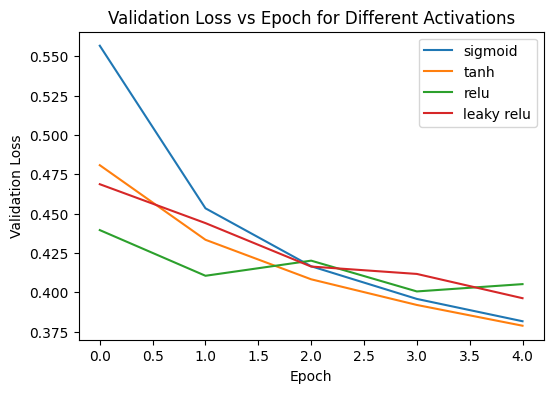

In [24]:
# plotting all 4 val loss curves together
plt.figure(figsize=(6,4))
plt.plot(sigmoid_history.history['val_loss'], label='sigmoid')
plt.plot(tanh_history.history['val_loss'], label='tanh')
plt.plot(relu_history.history['val_loss'], label='relu')
plt.plot(leaky_history.history['val_loss'], label='leaky relu')

plt.title("Validation Loss vs Epoch for Different Activations")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [25]:
#epoch 1 and last
print("sigmoid grad epoch 1:", sigmoid_logger.grad_history[0])
print("sigmoid grad last epoch:", sigmoid_logger.grad_history[-1])

print("relu grad epoch 1:", relu_logger.grad_history[0])
print("relu grad last epoch:", relu_logger.grad_history[-1])

sigmoid grad epoch 1: 0.00022222493
sigmoid grad last epoch: 0.00042952847
relu grad epoch 1: 0.0013942958
relu grad last epoch: 0.002346538


so by this we can see that for the sigmoid the learning is very less as compared to the relu as there is difference in both values for sigmoid and relu

so in short words the relu provides a better learning as compared to the sigmoid


In [26]:
#if output is 0 it is dead relu
W1_relu, b1_relu = relu_model.layers[0].get_weights()

Z1 = np.dot(X_val[:256], W1_relu) + b1_relu
A1 = relu(Z1)   #relu from p1

dead_units = np.all(A1 == 0, axis=0) #check all
dead_percentage = np.mean(dead_units) * 100
print("percentage of dead relu units:", dead_percentage, "%")

percentage of dead relu units: 5.46875 %


3.9% are 0 this is very small ratio and i think it is not that concerning but to name it this is the dying relu problem for which solution exists but here the number is small so we will ignore it the solution to solve the dying relu problem is >* Leaky Relu (0.01x,x)*

# PART 3

here i am using sample data set of diabetes which i explored on
https://scikit-learn.org/stable/datasets/toy_dataset.html

In [27]:
#CROSS ENTROPY MODEL
#using the same relu architecture from part 2 (128, 64)
ce_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

ce_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

ce_history = ce_model.fit(X_train, y_train_cat,
                           validation_data=(X_val, y_val_cat),
                           epochs=5, batch_size=128,
                           verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8123 - loss: 0.5328 - val_accuracy: 0.8543 - val_loss: 0.4004
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8647 - loss: 0.3775 - val_accuracy: 0.8597 - val_loss: 0.3796
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8787 - loss: 0.3337 - val_accuracy: 0.8625 - val_loss: 0.3662
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8865 - loss: 0.3088 - val_accuracy: 0.8539 - val_loss: 0.3860
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8934 - loss: 0.2904 - val_accuracy: 0.8568 - val_loss: 0.3809


In [28]:
y_test_cat = to_categorical(y_test, 10)

ce_test_loss, ce_test_acc = ce_model.evaluate(X_test, y_test_cat, verbose=0)
print("cross entropy test accuracy:", ce_test_acc)

cross entropy test accuracy: 0.8554999828338623


In [29]:
#MSE MODEL 
#same as above only loss function differ
mse_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

mse_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='mean_squared_error',
                   metrics=['accuracy'])

mse_history = mse_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=5, batch_size=128,
                             verbose=1)

mse_test_loss, mse_test_acc = mse_model.evaluate(X_test, y_test_cat, verbose=0)
print("mse test accuracy:", mse_test_acc)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8113 - loss: 0.0273 - val_accuracy: 0.8157 - val_loss: 0.0264
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8605 - loss: 0.0204 - val_accuracy: 0.8362 - val_loss: 0.0237
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8768 - loss: 0.0182 - val_accuracy: 0.8453 - val_loss: 0.0220
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8859 - loss: 0.0170 - val_accuracy: 0.8516 - val_loss: 0.0212
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8914 - loss: 0.0161 - val_accuracy: 0.8577 - val_loss: 0.0209
mse test accuracy: 0.8565000295639038


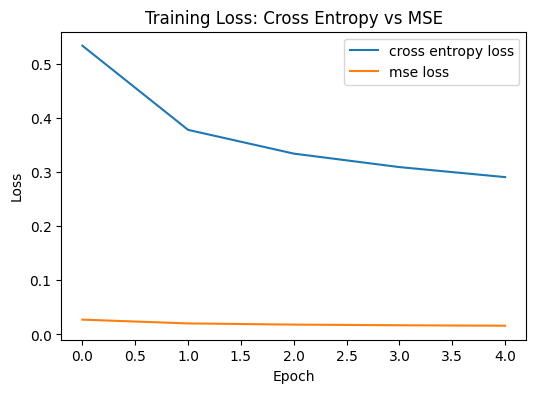

In [30]:
plt.figure(figsize=(6,4))
plt.plot(ce_history.history['loss'], label='cross entropy loss')
plt.plot(mse_history.history['loss'], label='mse loss')
plt.title("Training Loss: Cross Entropy vs MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Diabetes DataSet**

In [31]:
diabetes = load_diabetes()
X_diab = diabetes.data
y_diab = diabetes.target

print("X shape:", X_diab.shape)
print("y sample:", y_diab[0:5])

X shape: (442, 10)
y sample: [151.  75. 141. 206. 135.]


In [32]:
X_diab_train, X_diab_test, y_diab_train, y_diab_test = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_diab_train = scaler.fit_transform(X_diab_train)
X_diab_test = scaler.transform(X_diab_test)

In [33]:
reg_model = Sequential([
    Dense(40, input_dim=X_diab_train.shape[1], activation='relu'),
    Dense(20, activation='relu'),
    Dense(1)  #no activation function as this is regression
])

reg_model.compile(optimizer=Adam(learning_rate=0.01),
                   loss='mse',
                   metrics=['mae'])

reg_history = reg_model.fit(X_diab_train, y_diab_train,
                             validation_split=0.2,
                             epochs=50, batch_size=20,
                             verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 30334.4297 - mae: 155.3420 - val_loss: 20154.5039 - val_mae: 125.9475
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24347.4414 - mae: 137.0522 - val_loss: 13482.6709 - val_mae: 98.6056
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11748.7256 - mae: 87.0703 - val_loss: 5123.2432 - val_mae: 53.1759
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6488.7964 - mae: 63.3941 - val_loss: 4269.2212 - val_mae: 49.0459
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4729.0220 - mae: 53.8972 - val_loss: 3981.6387 - val_mae: 46.2518
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4072.0081 - mae: 50.1243 - val_loss: 3337.6580 - val_mae: 42.7917
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3585.3359 - mae: 47.0898 - val_loss: 3021.3425 - val_mae: 41.7592
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3327.4749 - mae: 45.4953 - val_loss: 2841.4187 - val_mae: 41.0427
Epoch 9/50

In [34]:
y_diab_pred = reg_model.predict(X_diab_test)

mse_val = mean_squared_error(y_diab_test, y_diab_pred)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_diab_test, y_diab_pred)

print("MSE:", mse_val)
print("RMSE:", rmse_val)
print("MAE:", mae_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step
MSE: 2609.661439002659
RMSE: 51.084845492598475
MAE: 40.752396015638716


When the MSE is combined with softmax it produces small gradients so by this the learning becomes slow but on the other hand corss-entropy with softmax the output is large as compared to MSE so it pushes the weights towards the correct answer

# PART 4

In [35]:
#Optimsers
def epochs_to_reach(history, target=0.85):
    val_acc = history.history['val_accuracy']

    epoch = 1

    for acc in val_acc:
        if acc >= target:
            return epoch
        epoch += 1

    return None
#loop for tracking epochs catch when accuracy gets 85

In [36]:
#SGD plain
sgd_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_model.compile(optimizer=SGD(learning_rate=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start = time.time()
sgd_history = sgd_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=20, batch_size=100,
                             verbose=1)
sgd_time = time.time() - start

print("sgd epochs to 85%:", epochs_to_reach(sgd_history))
print("sgd final val acc:", sgd_history.history['val_accuracy'][-1])
print("sgd wall clock time:", sgd_time)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6951 - loss: 1.0004 - val_accuracy: 0.7720 - val_loss: 0.6839
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7958 - loss: 0.6125 - val_accuracy: 0.8023 - val_loss: 0.5745
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8187 - loss: 0.5392 - val_accuracy: 0.8144 - val_loss: 0.5287
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8294 - loss: 0.5017 - val_accuracy: 0.8196 - val_loss: 0.5027
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8369 - loss: 0.4773 - val_accuracy: 0.8243 - val_loss: 0.4857
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8416 - loss: 0.4594 - val_accuracy: 0.8276 - val_loss: 0.4718
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8458 - loss: 0.4454 - val_accuracy: 0.8313 - val_loss: 0.4620
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8493 - loss: 0.4340 - val_accuracy: 0.

In [37]:
#SGD with momentum

sgd_mom_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_mom_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

start = time.time()
sgd_mom_history = sgd_mom_model.fit(X_train, y_train_cat,
                                     validation_data=(X_val, y_val_cat),
                                     epochs=20, batch_size=100,
                                     verbose=1)
sgd_mom_time = time.time() - start

print("sgd+momentum epochs to 85%:", epochs_to_reach(sgd_mom_history))
print("sgd+momentum final val acc:", sgd_mom_history.history['val_accuracy'][-1])
print("sgd+momentum wall clock time:", sgd_mom_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7874 - loss: 0.6193 - val_accuracy: 0.8422 - val_loss: 0.4555
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8495 - loss: 0.4259 - val_accuracy: 0.8538 - val_loss: 0.4069
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8643 - loss: 0.3815 - val_accuracy: 0.8611 - val_loss: 0.3799
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8741 - loss: 0.3525 - val_accuracy: 0.8674 - val_loss: 0.3641
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8813 - loss: 0.3307 - val_accuracy: 0.8709 - val_loss: 0.3528
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8863 - loss: 0.3131 - val_accuracy: 0.8714 - val_loss: 0.3492
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8924 - loss: 0.2983 - val_accuracy: 0.8711 - val_loss: 0.3498
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8966 - loss: 0.2853 - val_accuracy: 0.

In [38]:
#RMSProp
rms_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

rms_model.compile(optimizer=RMSprop(learning_rate=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start = time.time()
rms_history = rms_model.fit(X_train, y_train_cat,
                             validation_data=(X_val, y_val_cat),
                             epochs=20, batch_size=100,
                             verbose=1)
rms_time = time.time() - start

print("rmsprop epochs to 85%:", epochs_to_reach(rms_history))
print("rmsprop final val acc:", rms_history.history['val_accuracy'][-1])
print("rmsprop wall clock time:", rms_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7425 - loss: 0.9480 - val_accuracy: 0.7875 - val_loss: 0.5352
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8263 - loss: 0.4796 - val_accuracy: 0.8272 - val_loss: 0.4699
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8424 - loss: 0.4431 - val_accuracy: 0.8102 - val_loss: 0.5221
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8514 - loss: 0.4200 - val_accuracy: 0.8376 - val_loss: 0.4654
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8574 - loss: 0.4111 - val_accuracy: 0.8326 - val_loss: 0.4817
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8621 - loss: 0.4018 - val_accuracy: 0.8407 - val_loss: 0.6082
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8628 - loss: 0.4024 - val_accuracy: 0.8553 - val_loss: 0.4449
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8666 - loss: 0.3926 - val_accuracy: 0.

In [39]:
#Adam
adam_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

adam_model.compile(optimizer=Adam(learning_rate=0.01),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

start = time.time()
adam_history = adam_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=20, batch_size=100,
                               verbose=1)
adam_time = time.time() - start

print("adam epochs to 85%:", epochs_to_reach(adam_history))
print("adam final val acc:", adam_history.history['val_accuracy'][-1])
print("adam wall clock time:", adam_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7867 - loss: 0.6455 - val_accuracy: 0.8337 - val_loss: 0.4531
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8526 - loss: 0.4072 - val_accuracy: 0.8398 - val_loss: 0.4343
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8648 - loss: 0.3727 - val_accuracy: 0.8614 - val_loss: 0.3865
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8741 - loss: 0.3518 - val_accuracy: 0.8598 - val_loss: 0.3863
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8771 - loss: 0.3426 - val_accuracy: 0.8447 - val_loss: 0.4375
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8798 - loss: 0.3291 - val_accuracy: 0.8503 - val_loss: 0.4246
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8823 - loss: 0.3249 - val_accuracy: 0.8459 - val_loss: 0.4273
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8869 - loss: 0.3122 - val_accuracy: 0.

In [40]:
#TUNED LEARNING RATE PER OPTIMISER

In [41]:
# SGD tuned
sgd_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_tuned_model.compile(optimizer=SGD(learning_rate=0.1),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

start = time.time()
sgd_tuned_history = sgd_tuned_model.fit(X_train, y_train_cat,
                                         validation_data=(X_val, y_val_cat),
                                         epochs=20, batch_size=100,
                                         verbose=1)
sgd_tuned_time = time.time() - start

print("sgd tuned epochs to 85%:", epochs_to_reach(sgd_tuned_history))
print("sgd tuned final val acc:", sgd_tuned_history.history['val_accuracy'][-1])
print("sgd tuned wall clock time:", sgd_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7765 - loss: 0.6358 - val_accuracy: 0.7465 - val_loss: 0.6112
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8416 - loss: 0.4388 - val_accuracy: 0.7941 - val_loss: 0.5133
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8586 - loss: 0.3890 - val_accuracy: 0.8047 - val_loss: 0.5022
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8686 - loss: 0.3596 - val_accuracy: 0.8184 - val_loss: 0.4666
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8765 - loss: 0.3373 - val_accuracy: 0.8320 - val_loss: 0.4372
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8827 - loss: 0.3190 - val_accuracy: 0.8386 - val_loss: 0.4230
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8882 - loss: 0.3037 - val_accuracy: 0.8457 - val_loss: 0.4100
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8933 - loss: 0.2902 - val_accuracy: 0.

In [42]:
#SGD + momentum tuned
sgd_mom_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

sgd_mom_tuned_model.compile(optimizer=SGD(learning_rate=0.05, momentum=0.9),
                             loss='categorical_crossentropy',
                             metrics=['accuracy'])

start = time.time()
sgd_mom_tuned_history = sgd_mom_tuned_model.fit(X_train, y_train_cat,
                                                 validation_data=(X_val, y_val_cat),
                                                 epochs=20, batch_size=100,
                                                 verbose=1)
sgd_mom_tuned_time = time.time() - start

print("sgd+momentum tuned epochs to 85%:", epochs_to_reach(sgd_mom_tuned_history))
print("sgd+momentum tuned final val acc:", sgd_mom_tuned_history.history['val_accuracy'][-1])
print("sgd+momentum tuned wall clock time:", sgd_mom_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7998 - loss: 0.5559 - val_accuracy: 0.8520 - val_loss: 0.4119
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8541 - loss: 0.3994 - val_accuracy: 0.8662 - val_loss: 0.3630
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8700 - loss: 0.3541 - val_accuracy: 0.8683 - val_loss: 0.3509
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8789 - loss: 0.3254 - val_accuracy: 0.8705 - val_loss: 0.3425
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8857 - loss: 0.3083 - val_accuracy: 0.8673 - val_loss: 0.3623
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8915 - loss: 0.2935 - val_accuracy: 0.8652 - val_loss: 0.3666
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8957 - loss: 0.2793 - val_accuracy: 0.8583 - val_loss: 0.3801
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8991 - loss: 0.2683 - val_accuracy: 0.

In [44]:
#RMSProp tuned
rms_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

rms_tuned_model.compile(optimizer=RMSprop(learning_rate=0.001),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

start = time.time()
rms_tuned_history = rms_tuned_model.fit(X_train, y_train_cat,
                                         validation_data=(X_val, y_val_cat),
                                         epochs=20, batch_size=100,
                                         verbose=1)
rms_tuned_time = time.time() - start

print("rmsprop tuned epochs to 85%:", epochs_to_reach(rms_tuned_history))
print("rmsprop tuned final val acc:", rms_tuned_history.history['val_accuracy'][-1])
print("rmsprop tuned wall clock time:", rms_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7886 - loss: 0.5839 - val_accuracy: 0.8182 - val_loss: 0.4603
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8529 - loss: 0.3966 - val_accuracy: 0.8321 - val_loss: 0.4312
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8705 - loss: 0.3488 - val_accuracy: 0.8517 - val_loss: 0.3900
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8815 - loss: 0.3189 - val_accuracy: 0.8543 - val_loss: 0.3829
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8894 - loss: 0.2966 - val_accuracy: 0.8623 - val_loss: 0.3754
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8956 - loss: 0.2793 - val_accuracy: 0.8561 - val_loss: 0.3880
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9018 - loss: 0.2649 - val_accuracy: 0.8577 - val_loss: 0.3893
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9059 - loss: 0.2513 - val_accuracy: 0.

In [45]:
#Adam tuned
adam_tuned_model = Sequential([
    Dense(784, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

adam_tuned_model.compile(optimizer=Adam(learning_rate=0.001),
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

start = time.time()
adam_tuned_history = adam_tuned_model.fit(X_train, y_train_cat,
                                           validation_data=(X_val, y_val_cat),
                                           epochs=20, batch_size=100,
                                           verbose=1)
adam_tuned_time = time.time() - start

print("adam tuned epochs to 85%:", epochs_to_reach(adam_tuned_history))
print("adam tuned final val acc:", adam_tuned_history.history['val_accuracy'][-1])
print("adam tuned wall clock time:", adam_tuned_time)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8138 - loss: 0.5240 - val_accuracy: 0.8515 - val_loss: 0.4098
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8644 - loss: 0.3763 - val_accuracy: 0.8679 - val_loss: 0.3653
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8802 - loss: 0.3316 - val_accuracy: 0.8738 - val_loss: 0.3426
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8878 - loss: 0.3048 - val_accuracy: 0.8770 - val_loss: 0.3324
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8950 - loss: 0.2855 - val_accuracy: 0.8737 - val_loss: 0.3447
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9007 - loss: 0.2712 - val_accuracy: 0.8687 - val_loss: 0.3589
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9068 - loss: 0.2548 - val_accuracy: 0.8651 - val_loss: 0.3741
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9110 - loss: 0.2426 - val_accuracy: 0.

In [46]:
#table for compare
results_table = pd.DataFrame({
    "Optimiser": ["SGD", "SGD+Momentum", "RMSProp", "Adam"],
    "Learning rate": [0.1, 0.05, 0.001, 0.001],
    "Epochs to 85% val acc": [
        epochs_to_reach(sgd_tuned_history),
        epochs_to_reach(sgd_mom_tuned_history),
        epochs_to_reach(rms_tuned_history),
        epochs_to_reach(adam_tuned_history)
    ],
    "Final val accuracy": [
        sgd_tuned_history.history['val_accuracy'][-1],
        sgd_mom_tuned_history.history['val_accuracy'][-1],
        rms_tuned_history.history['val_accuracy'][-1],
        adam_tuned_history.history['val_accuracy'][-1]
    ],
    "Wall clock time (s)": [sgd_tuned_time, sgd_mom_tuned_time, rms_tuned_time, adam_tuned_time]
})

results_table

,Optimiser,Learning rate,Epochs to 85% val acc,Final val accuracy,Wall clock time (s)
0,SGD,0.100,8,0.870167,30.564634
1,SGD+Momentum,0.050,1,0.851833,31.391603
2,RMSProp,0.001,3,0.876167,31.347397
3,Adam,0.001,1,0.860583,32.089134


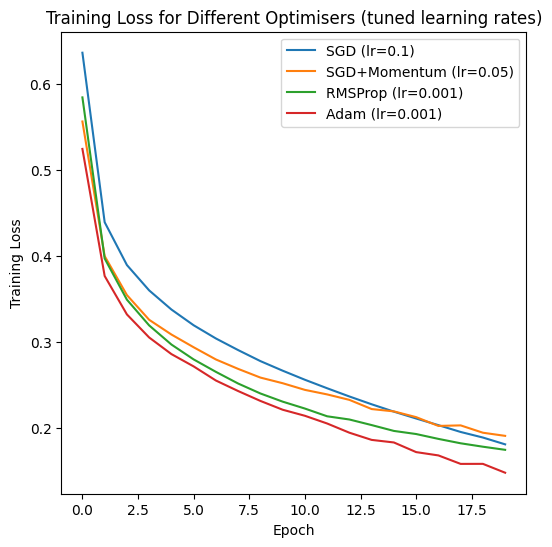

In [50]:
plt.figure(figsize=(6,6))
plt.plot(sgd_tuned_history.history['loss'], label='SGD (lr=0.1)')
plt.plot(sgd_mom_tuned_history.history['loss'], label='SGD+Momentum (lr=0.05)')
plt.plot(rms_tuned_history.history['loss'], label='RMSProp (lr=0.001)')
plt.plot(adam_tuned_history.history['loss'], label='Adam (lr=0.001)')

plt.title("Training Loss for Different Optimisers (tuned learning rates)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.show()

Based on the Results I would choose RMSProp beacuse it reaches validaton accuracy in 3 epochs and further more it has final accuracy of 87% which is best among all even if i see the time it is win win situation